In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [22]:
cols_to_use = ['CrashSeverity', 'CrashDateTime', 'NumberOfUnits', 'LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided', 'IntersectionOrApproachRelated', 'NumberOfApproaches', 'WithinInterchangeArea', 'Latitude', 'Longitude','RoadContour','RoadCondition','RoadSurface', 'AnimalRelated','AnimalDeerRelated','AlcoholRelated','DrugRelated','BicycleRelated','MotorCycleRelated','SpeedRelated','PedestrianRelated',	'SemiTruckRelated','SmallTruckRelated','YouthRelated','TeenRelated','DUI21Related','SeniorRelated',	'CommercialRelated','CommercialAtFault']

df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv", usecols=cols_to_use, low_memory=False)

#print(df)


In [23]:
#arcgis_db = df[['CrashSeverity', 'Latitude', 'Longitude']]
#print(arcgis_db)

#arcgis_db.to_csv('raw_crash_data.csv', index=False)

In [24]:
#df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv")
#df.drop(columns=['LocalReportNumber','DocumentNumber','HitSkip', 'SecondaryCrash','UnitInError','County','FIPSPlaceCode', 'PhotosTaken', 'OH2', 'OH3','OH1P','OHOther','PrivateProperty','ReportingAgencyNCIC','Narrative','ReportTakenBy','Supplement','CrashReportedDateTime','DispatchedDateTime','ArrivedDateTime','SceneClearedDateTime','OtherInvestigationTime','OfficerName','OfficerBadgeNumber','CheckedByOfficerName','CheckedByBadgeNumber'], inplace=True)

In [25]:
df["CrashDateTime"] = pd.to_datetime(df["CrashDateTime"])
df["Year"] = df["CrashDateTime"].dt.year
df["Month"] = df["CrashDateTime"].dt.month
df["Day"] = df["CrashDateTime"].dt.day
df["Hour"] = df["CrashDateTime"].dt.hour
df["Minute"] = df["CrashDateTime"].dt.minute
df = df.drop(columns=["CrashDateTime"])

In [73]:
le = LabelEncoder()

SeverityOrder = {'Property Damage Only': 0, 'Injury Possible': 1, 'Minor Injury Suspected': 2, 'Serious Injury Suspected': 3, 'Fatal': 4}
df['EncodedCrashSeverity'] = df['CrashSeverity'].map(SeverityOrder)

label_map = dict(zip(df['CrashSeverity'], df['EncodedCrashSeverity']))

#mapping = {label: index for index, label in enumerate(le.classes_)}

print(SeverityOrder)

{'Property Damage Only': 0, 'Injury Possible': 1, 'Minor Injury Suspected': 2, 'Serious Injury Suspected': 3, 'Fatal': 4}


In [27]:
# List of feature and target columns
x = df.drop(columns=['CrashSeverity', 'EncodedCrashSeverity'])
y = df['EncodedCrashSeverity']

In [28]:
#Split testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [29]:
#Separate numeric and categorical features
numeric_features = x.select_dtypes(include="number").columns
categorical_features = x.select_dtypes(exclude="number").columns
print(numeric_features)
print(categorical_features)

Index(['NumberOfUnits', 'Latitude', 'Longitude', 'NumberOfApproaches', 'Year',
       'Month', 'Day', 'Hour', 'Minute'],
      dtype='str')
Index(['IntersectionOrApproachRelated', 'WithinInterchangeArea',
       'MannerOfCollision', 'Weather', 'LightCondition', 'RoadwayDivided',
       'RoadContour', 'RoadCondition', 'RoadSurface', 'AnimalRelated',
       'AnimalDeerRelated', 'AlcoholRelated', 'DrugRelated', 'BicycleRelated',
       'MotorCycleRelated', 'SpeedRelated', 'PedestrianRelated',
       'SemiTruckRelated', 'SmallTruckRelated', 'YouthRelated', 'TeenRelated',
       'DUI21Related', 'SeniorRelated', 'CommercialRelated',
       'CommercialAtFault'],
      dtype='str')


Core code

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='most_frequent')), # error in manner_of_collision for angle
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [31]:
from sklearn.compose import ColumnTransformer

data_transformer = ColumnTransformer(
  transformers = [
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, 
      categorical_features)
    ])

transformed_data = data_transformer.fit_transform(X_train)

#column_names = data_transformer.get_feature_names_out()

In [ ]:
#Feature selection
from sklearn.feature_selection import SelectFromModel
feature_selector = SelectFromModel(
    estimator=XGBClassifier(
        n_estimators=200,
        random_state=42
    ),
    threshold="1.25*mean"
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2628422867.py, line 6)

In [33]:
model_1 = XGBClassifier(
    n_estimators=75,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
#parameters determined by bayesian optimization

In [34]:
xgb_pipeline =  Pipeline(steps = [
    ('preprocessing', data_transformer),
    ("feature_selection", feature_selector),
    ('XGB', model_1)
    ])

#xgb_pipeline = xgb_pipeline.fit(X_train, y_train)
#prediction = xgb_pipeline.predict(X_test)

In [35]:
#Make weights count to account for uneven split of data

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#sklearn.set_config(enable_metadata_routing=True)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights_dict[cls] for cls in y_train])

xgb_pipeline = xgb_pipeline.fit(X_train, y_train, XGB__sample_weight=sample_weights)
y_pred = xgb_pipeline.predict(X_test)

Model Analysis and Comparison

In [36]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro-Averaged F1 Score: {macro_f1:.4f}")

#Precision: False positives (higher is better)
#Recall (Sensitivity): How many actual positives were detected (higher is better)
#F1: harmonic mean of Precision and Recall

              precision    recall  f1-score   support

           0       0.88      0.31      0.46      1372
           1       0.10      0.31      0.15       143
           2       0.20      0.52      0.29       330
           3       0.19      0.28      0.23        53
           4       0.13      0.50      0.21        14

    accuracy                           0.35      1912
   macro avg       0.30      0.39      0.27      1912
weighted avg       0.68      0.35      0.40      1912

Macro-Averaged F1 Score: 0.2671


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score

#strategy "most_frequent" always predicts the majority class
dummy_majority = DummyClassifier(strategy="most_frequent")
dummy_majority.fit(X_train, y_train)

dummy_preds = dummy_majority.predict(X_test)

print(classification_report(y_test, dummy_preds))

accuracy = accuracy_score(y_test, dummy_preds)

# 3. Print the result
print(f"Test Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

           0       0.72      1.00      0.84      1372
           1       0.00      0.00      0.00       143
           2       0.00      0.00      0.00       330
           3       0.00      0.00      0.00        53
           4       0.00      0.00      0.00        14

    accuracy                           0.72      1912
   macro avg       0.14      0.20      0.17      1912
weighted avg       0.51      0.72      0.60      1912

Test Accuracy: 0.7176


c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Hyperparameter optimization

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'XGB__n_estimators': [50, 75, 100],
    'XGB__learning_rate': [0.05, 0.1, 0.2],
    'XGB__max_depth': [3, 5, 7],
    'XGB__subsample': [0.8, 1.0],
    'XGB__colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline, 
    param_grid=param_grid, 
    cv=3, #cross validation folds
    scoring='accuracy', 
    n_jobs=-1, #uses all cpu cores
    verbose=1 #print what it's doing
)

grid_search.fit(X_train, y_train)

print("\nSearch Results")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"Final Test Accuracy with Best Model: {test_accuracy:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Search Results
Best Parameters: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.2, 'XGB__max_depth': 3, 'XGB__n_estimators': 100, 'XGB__subsample': 0.8}
Best Cross-Validation Score: 0.7297
Final Test Accuracy with Best Model: 0.7249


Attempting to print feature importance

In [ ]:
import numpy as np
def get_pipeline_feature_names(pipeline):
    #get names directly from the pipeline
    preprocessor = pipeline.named_steps['preprocessing']
    ohe_categories = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    all_names = np.concatenate([numeric_features, ohe_categories])
    
    #only include names in feature_selection
    selector_mask = pipeline.named_steps['feature_selection'].get_support()
    return all_names[selector_mask]

feature_names = get_pipeline_feature_names(xgb_pipeline)
importances = xgb_pipeline.named_steps['XGB'].feature_importances_

                                        feature  importance
10                            DrugRelated_False    0.238862
12                      MotorCycleRelated_False    0.087687
8                           AnimalRelated_False    0.085594
9                       AnimalDeerRelated_False    0.078520
13                      PedestrianRelated_False    0.069245
5   MannerOfCollision_Sideswipe; same direction    0.069114
2                     MannerOfCollision_Head-on    0.055899
3                    MannerOfCollision_Rear-end    0.054329
11                         BicycleRelated_False    0.046674
1                     MannerOfCollision_Backing    0.038936
Model Score: 0.3483


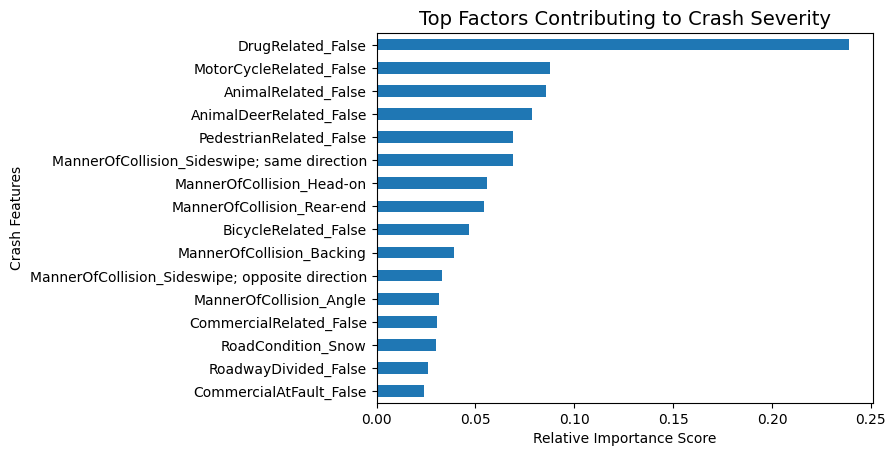

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#clean_names = [name.replace('cat__', '').replace('num__', '').replace('_', ' ') for name in column_names]

feat_imp_graph = pd.Series(importances, index=feature_names)
axis = feat_imp_graph.nlargest(25).plot(kind='barh')

axis.invert_yaxis()
axis.set_title("Top Factors Contributing to Crash Severity", fontsize=14)
axis.set_xlabel("Relative Importance Score")
axis.set_ylabel("Crash Features")

plt.show()

C:\Users\alyss\AppData\Local\Temp\ipykernel_38148\145463467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=non_drug_crashes, x='EncodedCrashSeverity', palette='viridis')


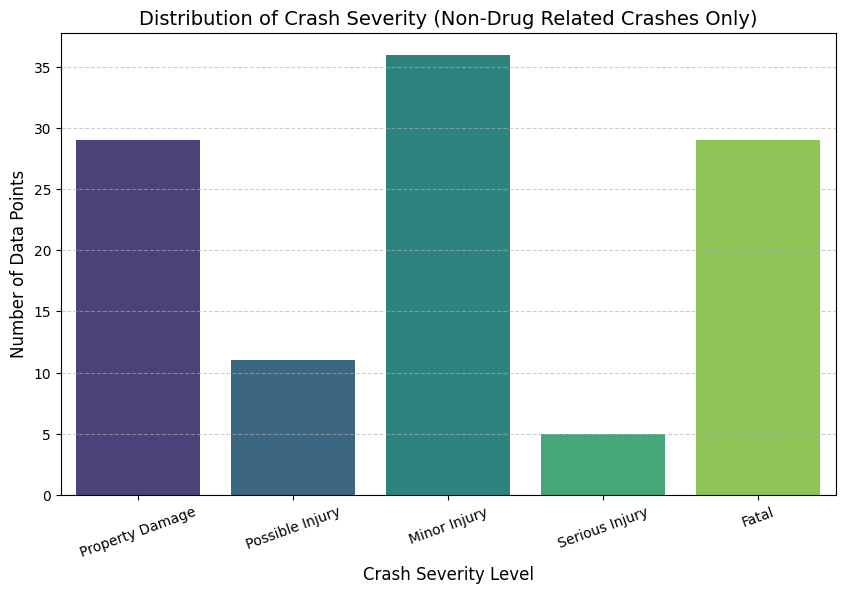

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

non_drug_crashes = df[df['DrugRelated'].isin([0])]

plt.figure(figsize=(10, 6))

sns.countplot(data=non_drug_crashes, x='EncodedCrashSeverity', palette='viridis')

plt.title('Distribution of Crash Severity (Non-Drug Related Crashes Only)', fontsize=14)
plt.xlabel('Crash Severity Level', fontsize=12)
plt.ylabel('Number of Data Points', fontsize=12)

severity_labels = ['Property Damage', 'Possible Injury', 'Minor Injury', 'Serious Injury', 'Fatal']
plt.xticks(ticks=range(5), labels=severity_labels, rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

To do in the future: Cross validation fold score


To do: 

In [ ]:
#Cross correlation matrix?


Exporting xgboost predictions

In [ ]:
import geopandas as gpd
df['prediction'] = xgb_pipeline.predict(x)

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

gdf.to_file('ordered_predictions.geojson', driver='GeoJSON')


import os
print(os.getcwd())

c:\Users\alyss\Downloads\csci 2026\jr_is\jris\rf_code
